In [9]:
import pandas as pd

df = pd.read_csv("kozmetik_dataset_preprocessing_end.csv")

df.head(10)

,price,old_price,rating,review_count,sales_last_month,discount_rate,clean_title,brand_extracted,category
0,355.00,355.00,4.3,102,287,0.0,golden rose longstay liquid matte lipstick no ...,Golden Rose,Makyaj
1,284.90,284.90,3.9,32,50,0.0,note cosmetics 3 in 1 healthy skin tinted mois...,Note Cosmetics,Cilt Bakımı
2,350.95,350.95,4.0,28,425,0.0,note cosmetics collagen concealer 01 kolajen i...,Note Cosmetics,Makyaj
3,254.90,254.90,4.4,74,80,0.0,note cosmetics mineral concealer 202 spf 15 go...,Note Cosmetics,Makyaj
4,499.00,499.00,4.3,13,500,0.0,l oreal paris telescopic maskara siyah,Lore,Makyaj
5,130.90,130.90,4.7,937,600,0.0,blistex medplus stick kuru ve catlams dudaklar...,Blistex,Cilt Bakımı
6,689.90,344.95,4.3,420,900,-100.0,cream co su bazl moisturizer nemlendirici aydn...,Cream Co,Cilt Bakımı
7,134.50,134.50,4.5,1,600,0.0,the purest solutions gozenek ve siyah nokta go...,The Purest,Cilt Bakımı
8,119.93,119.93,4.5,676,300,0.0,l oreal paris elseve mucizevi yag sac guzelles...,L'Oreal Paris,Other
9,427.46,427.46,4.5,382,50,0.0,l oreal paris lumi blush likit allk 630 glowy ...,L'Oreal Paris,Makyaj


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             249 non-null    float64
 1   old_price         249 non-null    float64
 2   rating            249 non-null    float64
 3   review_count      249 non-null    int64  
 4   sales_last_month  249 non-null    int64  
 5   discount_rate     249 non-null    float64
 6   clean_title       249 non-null    object 
 7   brand_extracted   249 non-null    object 
 8   category          249 non-null    object 
dtypes: float64(4), int64(2), object(3)
memory usage: 17.6+ KB


In [31]:
import matplotlib.pyplot as plt
import numpy as np
from kmodes.kprototypes import KPrototypes

df_cluster = df.copy()

features = [
    "brand_extracted",
    "category",
    "old_price",
    "price",
    "rating",
    "sales_last_month",
]
X_cluster = df_cluster[features]

categorical_idx = [0, 1]

X_cluster = X_cluster.dropna().reset_index(drop=True)

kproto = KPrototypes(n_clusters=3, init="Cao", n_init=5, verbose=1)

clusters = kproto.fit_predict(X_cluster, categorical=categorical_idx)

X_cluster["Segment"] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 48, ncost: 14723505.851715352
Run: 1, iteration: 2/100, moves: 5, ncost: 14590720.543764949
Run: 1, iteration: 3/100, moves: 3, ncost: 14575082.229072303
Run: 1, iteration: 4/100, moves: 1, ncost: 14573012.565175617
Run: 1, iteration: 5/100, moves: 0, ncost: 14573012.565175617
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 106, ncost: 21487203.61590525
Run: 2, iteration: 2/100, moves: 60, ncost: 15269606.343554297
Run: 2, iteration: 3/100, moves: 25, ncost: 14596869.00411476
Run: 2, iteration: 4/100, moves: 4, ncost: 14575082.229072295
Run: 2, iteration: 5/100, moves: 1, ncost: 14573012.56517561
Run: 2, iteration: 6/100, moves: 0, ncost: 14573012.56517561
Init: initializing centroids
Init: initializing clusters
Init: initializing centr

In [32]:
print("--- Sayısal Özelliklerin Segment Ortalamaları ---")
print(
    X_cluster.groupby("Segment")[
        ["old_price", "price", "rating", "sales_last_month"]
    ].mean()
)

print("\n--- Her Segmentte En Çok Tekrar Eden Marka ve Kategoriler ---")
for i in range(3):
    segment_data = X_cluster[X_cluster["Segment"] == i]
    top_brand = segment_data["brand_extracted"].mode()[0]
    top_cat = segment_data["category"].mode()[0]
    print(
        f"Segment {i} -> En Baskın Marka: {top_brand} | En Baskın Kategori: {top_cat}"
    )

--- Sayısal Özelliklerin Segment Ortalamaları ---
          old_price        price    rating  sales_last_month
Segment                                                     
0        452.175385  1426.951538  4.340385        331.826923
1        464.167079   535.822809  4.344944        284.865169
2        188.418148   191.325185  4.164815        270.000000

--- Her Segmentte En Çok Tekrar Eden Marka ve Kategoriler ---
Segment 0 -> En Baskın Marka: doa kozmetik | En Baskın Kategori: Other
Segment 1 -> En Baskın Marka: doa kozmetik | En Baskın Kategori: Makyaj
Segment 2 -> En Baskın Marka: doa kozmetik | En Baskın Kategori: Other


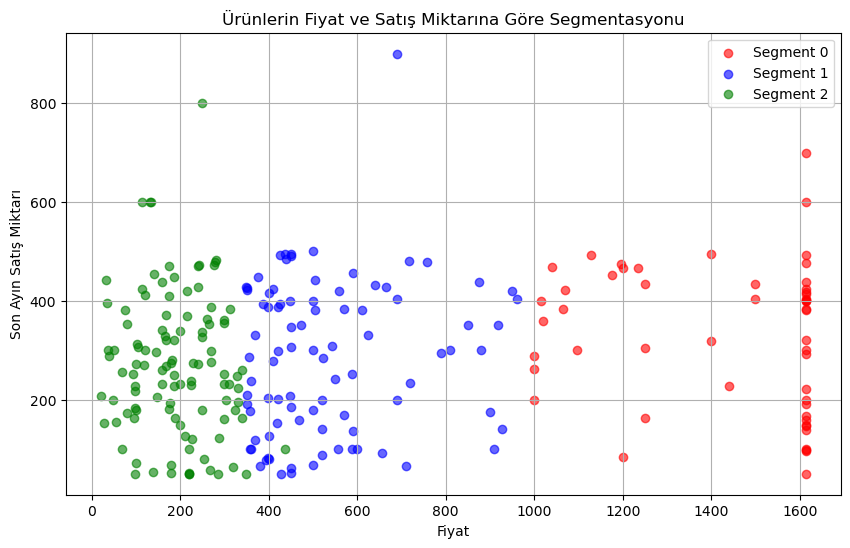

In [33]:
plt.figure(figsize=(10, 6))

colors = ["red", "blue", "green"]
for i in range(3):
    segmented_df = X_cluster[X_cluster["Segment"] == i]
    plt.scatter(
        segmented_df["price"],
        segmented_df["sales_last_month"],
        c=colors[i],
        label=f"Segment {i}",
        alpha=0.6,
    )

plt.title("Ürünlerin Fiyat ve Satış Miktarına Göre Segmentasyonu")
plt.xlabel("Fiyat")
plt.ylabel("Son Ayın Satış Miktarı")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
premium_df["discount_rate"] = (
    premium_df["old_price"] - premium_df["price"]
) / premium_df["old_price"]

X_indirimli = premium_df[["log_price", "rating", "discount_rate"]]
X_indirimli = sm.add_constant(X_indirimli)

y_indirimli = premium_df["log_sales"]

model_indirimli = sm.OLS(y_indirimli, X_indirimli).fit()
print(model_indirimli.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     2.730
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0541
Time:                        17:48:45   Log-Likelihood:                -40.184
No. Observations:                  52   AIC:                             88.37
Df Residuals:                      48   BIC:                             96.17
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.3514      3.797      1.410

In [39]:
X_cluster["discount_rate"] = (
    X_cluster["old_price"] - X_cluster["price"]
) / X_cluster["old_price"]

discount_analysis = (
    X_cluster.groupby("category")[["discount_rate", "sales_last_month"]]
    .mean()
    .sort_values(by="discount_rate", ascending=False)
)
print(discount_analysis)

             discount_rate  sales_last_month
category                                    
Aksesuar         -0.238741        268.884615
Other            -0.583619        308.482353
Makyaj           -0.799459        250.486111
Cilt Bakımı      -0.826377        334.363636
Parfüm           -2.978641        356.571429


In [40]:
## yeşil segment için analiz

In [41]:
economic_df = X_cluster[X_cluster["Segment"] == 2].copy()

economic_df = economic_df[(economic_df["price"] > 0) & (economic_df["sales_last_month"] > 0)]

economic_df["log_price"] = np.log(economic_df["price"])
economic_df["log_sales"] = np.log(economic_df["sales_last_month"])
economic_df["discount_rate"] = (economic_df["old_price"] - economic_df["price"]) / economic_df["old_price"]

X_yesil = economic_df[["log_price", "rating", "discount_rate"]]
X_yesil = sm.add_constant(X_yesil)
y_yesil = economic_df["log_sales"]

model_yesil = sm.OLS(y_yesil, X_yesil).fit()
print(model_yesil.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.208
Date:                Fri, 05 Jun 2026   Prob (F-statistic):              0.311
Time:                        17:52:45   Log-Likelihood:                -105.35
No. Observations:                 108   AIC:                             218.7
Df Residuals:                     104   BIC:                             229.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             6.3206      0.657      9.621

In [42]:
yesil_kategori = (
    X_cluster[X_cluster["Segment"] == 2]
    .groupby("category")[["discount_rate", "sales_last_month"]]
    .mean()
    .sort_values(by="sales_last_month", ascending=False)
)
print("\n--- Yeşil Segment Kategori Özeti ---")
print(yesil_kategori)


--- Yeşil Segment Kategori Özeti ---
             discount_rate  sales_last_month
category                                    
Cilt Bakımı      -0.020217        339.090909
Other            -0.058333        277.050000
Aksesuar          0.000000        262.280000
Makyaj            0.000000        243.468750
